In [208]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import matplotlib
import seaborn as sns
matplotlib.rcParams["figure.figsize"]=(20,10)
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer

In [209]:
df1=pd.read_csv("Bengaluru_House_Data.csv")

In [210]:
df1.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [211]:
df1.shape

(13320, 9)

In [212]:
df1.groupby('area_type')['area_type'].agg('count')

area_type
Built-up  Area          2418
Carpet  Area              87
Plot  Area              2025
Super built-up  Area    8790
Name: area_type, dtype: int64

In [213]:
df2=df1.drop(['area_type','society','availability'],axis='columns')

In [214]:
df2.head()

,location,size,total_sqft,bath,balcony,price
0,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Kothanur,2 BHK,1200,2.0,1.0,51.00


In [215]:
df2.isnull().sum()

location        1
size           16
total_sqft      0
bath           73
balcony       609
price           0
dtype: int64

In [216]:
df2['balcony'].nunique()

4

In [217]:
df2['balcony'].fillna(df2['balcony'].median(),inplace=True)

In [218]:
df2.isna().sum()

location       1
size          16
total_sqft     0
bath          73
balcony        0
price          0
dtype: int64

In [219]:
df3=df2.dropna()

In [220]:
df3.isna().sum()

location      0
size          0
total_sqft    0
bath          0
balcony       0
price         0
dtype: int64

In [221]:
df3.shape

(13246, 6)

In [222]:
df3['bhk']=df3['size'].apply(lambda x: int(x.split(' ')[0]))

C:\Users\subas\AppData\Local\Temp\ipykernel_20228\2989175054.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['bhk']=df3['size'].apply(lambda x: int(x.split(' ')[0]))


In [223]:
df3.head()

,location,size,total_sqft,bath,balcony,price,bhk
0,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,1.0,51.00,2


In [224]:
df3.drop('size',axis='columns',inplace=True)

C:\Users\subas\AppData\Local\Temp\ipykernel_20228\1814700919.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3.drop('size',axis='columns',inplace=True)


In [225]:
df3.head()

,location,total_sqft,bath,balcony,price,bhk
0,Electronic City Phase II,1056,2.0,1.0,39.07,2
1,Chikka Tirupathi,2600,5.0,3.0,120.00,4
2,Uttarahalli,1440,2.0,3.0,62.00,3
3,Lingadheeranahalli,1521,3.0,1.0,95.00,3
4,Kothanur,1200,2.0,1.0,51.00,2


In [226]:
cols=list(df3.columns)
cols[-2],cols[-1]=cols[-1],cols[-2]
df3=df3[cols]

In [227]:
df3.head()

,location,total_sqft,bath,balcony,bhk,price
0,Electronic City Phase II,1056,2.0,1.0,2,39.07
1,Chikka Tirupathi,2600,5.0,3.0,4,120.00
2,Uttarahalli,1440,2.0,3.0,3,62.00
3,Lingadheeranahalli,1521,3.0,1.0,3,95.00
4,Kothanur,1200,2.0,1.0,2,51.00


In [228]:
df3['bhk'].unique()

array([ 2,  4,  3,  6,  1,  8,  7,  5, 11,  9, 27, 10, 19, 16, 43, 14, 12,
       13, 18], dtype=int64)

In [229]:
df3[df3['bhk']>10]

,location,total_sqft,bath,balcony,bhk,price
459,1 Giri Nagar,5000,9.0,3.0,11,360.0
1718,2Electronic City Phase II,8000,27.0,0.0,27,230.0
1768,1 Ramamurthy Nagar,1200,11.0,0.0,11,170.0
3379,1Hanuman Nagar,2000,16.0,2.0,19,490.0
3609,Koramangala Industrial Layout,10000,16.0,2.0,16,550.0
3853,1 Annasandrapalya,1200,6.0,3.0,11,150.0
4684,Munnekollal,2400,40.0,0.0,43,660.0
4916,1Channasandra,1250,15.0,0.0,14,125.0
6533,Mysore Road,2232,6.0,2.0,12,300.0
7979,1 Immadihalli,6000,12.0,2.0,11,150.0


In [230]:
df3['total_sqft'].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [231]:
def is_float(x):
    try:
        float(x)
        return True
    except:
        return False

In [232]:
df3[~df3['total_sqft'].apply(lambda x: is_float(x))].sample(10)

,location,total_sqft,bath,balcony,bhk,price
4122,Tumkur Road,1076 - 1199,2.0,0.0,2,48.905
11583,Bommanahalli,1215 - 1495,2.0,0.0,2,73.170
1712,Singena Agrahara,1500Sq. Meter,3.0,1.0,3,95.000
5453,Kannur,3Cents,6.0,3.0,6,75.000
6333,Harohalli,2.09Acres,2.0,0.0,2,200.000
13059,Harlur,1200 - 1470,2.0,0.0,2,72.760
11178,Hennur Road,1550 - 1590,3.0,0.0,3,75.990
13265,Hoodi,1133 - 1384,2.0,0.0,2,59.135
188,KR Puram,1015 - 1540,2.0,0.0,2,56.800
10488,2 Bedroom Furnished Farm House in Kolar Road,1.25Acres,2.0,2.0,2,200.000


In [233]:
df3.shape

(13246, 6)

In [234]:
def convert_to_numeric(x):
    if '-'in x:
        tokens=x.split('-')
        try:
            return ((float(tokens[0])+float(tokens[1]))/2)
        except:
            return None
    else:
         try:
            return float(x)
         except:
            return None

In [235]:
convert_to_numeric('117Sq. Yards')

In [236]:
df3['total_sqft'].apply(convert_to_numeric)

0        1056.0
1        2600.0
2        1440.0
3        1521.0
4        1200.0
          ...  
13315    3453.0
13316    3600.0
13317    1141.0
13318    4689.0
13319     550.0
Name: total_sqft, Length: 13246, dtype: float64

In [237]:
df4=df3.copy()
df4['total_sqft']=df3['total_sqft'].apply(convert_to_numeric)

In [238]:
df4.sample(20)

,location,total_sqft,bath,balcony,bhk,price
8139,Raja Rajeshwari Nagar,1196.0,2.0,2.0,2,40.54
8235,Rachenahalli,1050.0,2.0,2.0,2,52.50
4756,Jigani,1408.0,2.0,0.0,3,55.00
11435,Kamala Nagar,2800.0,3.0,1.0,3,400.00
11609,Hoodi,1447.0,3.0,2.0,2,76.00
5164,Nagarbhavi,1250.0,3.0,0.0,4,175.00
7959,Subramanyapura,1400.0,2.0,1.0,3,55.00
9032,Cambridge Layout,1756.0,3.0,2.0,3,307.00
11990,Chikkadunnasandra,1138.0,2.0,1.0,2,32.00
1373,Koramangala,1835.0,2.0,3.0,3,155.00


In [239]:
df4.shape

(13246, 6)

In [240]:
df4.isnull().sum()

location       0
total_sqft    46
bath           0
balcony        0
bhk            0
price          0
dtype: int64

In [241]:
df5=df4.dropna()

In [242]:
df5.shape

(13200, 6)

In [243]:
df5.isnull().sum()

location      0
total_sqft    0
bath          0
balcony       0
bhk           0
price         0
dtype: int64

In [244]:
df5.head()

,location,total_sqft,bath,balcony,bhk,price
0,Electronic City Phase II,1056.0,2.0,1.0,2,39.07
1,Chikka Tirupathi,2600.0,5.0,3.0,4,120.00
2,Uttarahalli,1440.0,2.0,3.0,3,62.00
3,Lingadheeranahalli,1521.0,3.0,1.0,3,95.00
4,Kothanur,1200.0,2.0,1.0,2,51.00


In [245]:
len(df5['location'].unique())

1298

In [246]:
df5.location=df5.location.apply(lambda x: x.strip())

C:\Users\subas\AppData\Local\Temp\ipykernel_20228\2059754047.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5.location=df5.location.apply(lambda x: x.strip())


In [247]:
df5.head()

,location,total_sqft,bath,balcony,bhk,price
0,Electronic City Phase II,1056.0,2.0,1.0,2,39.07
1,Chikka Tirupathi,2600.0,5.0,3.0,4,120.00
2,Uttarahalli,1440.0,2.0,3.0,3,62.00
3,Lingadheeranahalli,1521.0,3.0,1.0,3,95.00
4,Kothanur,1200.0,2.0,1.0,2,51.00


In [248]:
location_stats= df5.groupby('location')['location'].agg('count').sort_values(ascending=False)
location_stats

location
Whitefield               533
Sarjapur  Road           392
Electronic City          304
Kanakpura Road           264
Thanisandra              235
                        ... 
1 Giri Nagar               1
Kanakapura Road,           1
Kanakapura main  Road      1
Kannur                     1
whitefiled                 1
Name: location, Length: 1287, dtype: int64

In [249]:
df5.location.value_counts().sort_values(ascending=False)

location
Whitefield                              533
Sarjapur  Road                          392
Electronic City                         304
Kanakpura Road                          264
Thanisandra                             235
                                       ... 
Electronic City Phase 1,                  1
Chuchangatta Colony                       1
Hanuman Nagar                             1
Kengeri Satellite Town KHB Apartment      1
Abshot Layout                             1
Name: count, Length: 1287, dtype: int64

In [250]:
len(location_stats)

1287

In [251]:
location_less_than_10= location_stats[location_stats<=10]

In [252]:
location_less_than_10

location
Sadashiva Nagar          10
Naganathapura            10
Basapura                 10
Nagadevanahalli          10
Kalkere                  10
                         ..
1 Giri Nagar              1
Kanakapura Road,          1
Kanakapura main  Road     1
Kannur                    1
whitefiled                1
Name: location, Length: 1047, dtype: int64

In [253]:
df5['location']=df5['location'].apply(lambda x: 'other' if x in location_less_than_10 else x)

C:\Users\subas\AppData\Local\Temp\ipykernel_20228\2366688541.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['location']=df5['location'].apply(lambda x: 'other' if x in location_less_than_10 else x)


In [254]:
len(df5.location.unique())

241

In [255]:
df5.sample(10)

,location,total_sqft,bath,balcony,bhk,price
4994,Harlur,1174.0,2.0,1.0,2,75.000
10267,Sarjapura - Attibele Road,1090.0,2.0,1.0,2,37.000
12992,other,1200.0,4.0,2.0,5,200.000
7053,Uttarahalli,1163.0,2.0,2.0,2,68.000
959,Kammasandra,657.5,1.0,0.0,1,18.410
9885,other,1900.0,3.0,2.0,3,190.000
8029,Bisuvanahalli,873.0,2.0,1.0,3,40.000
4190,Kanakpura Road,458.0,1.0,0.0,1,19.695
8682,other,8400.0,5.0,2.0,4,1675.000
6264,HBR Layout,1656.0,3.0,2.0,3,90.000


In [256]:
df5.shape


(13200, 6)

In [257]:
df5.total_sqft.describe()['mean']

1555.3027829545454

In [258]:
df5.bhk.describe()['mean']

2.8008333333333333

In [259]:
df5.total_sqft.mean()/df5.bhk.mean()

555.3000117659788

In [260]:
df5['unit_area']=df5.total_sqft/df5.bhk
df5.unit_area

C:\Users\subas\AppData\Local\Temp\ipykernel_20228\1808258979.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['unit_area']=df5.total_sqft/df5.bhk


0         528.00
1         650.00
2         480.00
3         507.00
4         600.00
          ...   
13315     690.60
13316     900.00
13317     570.50
13318    1172.25
13319     550.00
Name: unit_area, Length: 13200, dtype: float64

In [261]:
df5.unit_area.describe()

count    13200.000000
mean       573.847262
std        388.079980
min          0.250000
25%        473.000000
50%        552.000000
75%        625.000000
max      26136.000000
Name: unit_area, dtype: float64

C:\Users\subas\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='unit_area', ylabel='Count'>

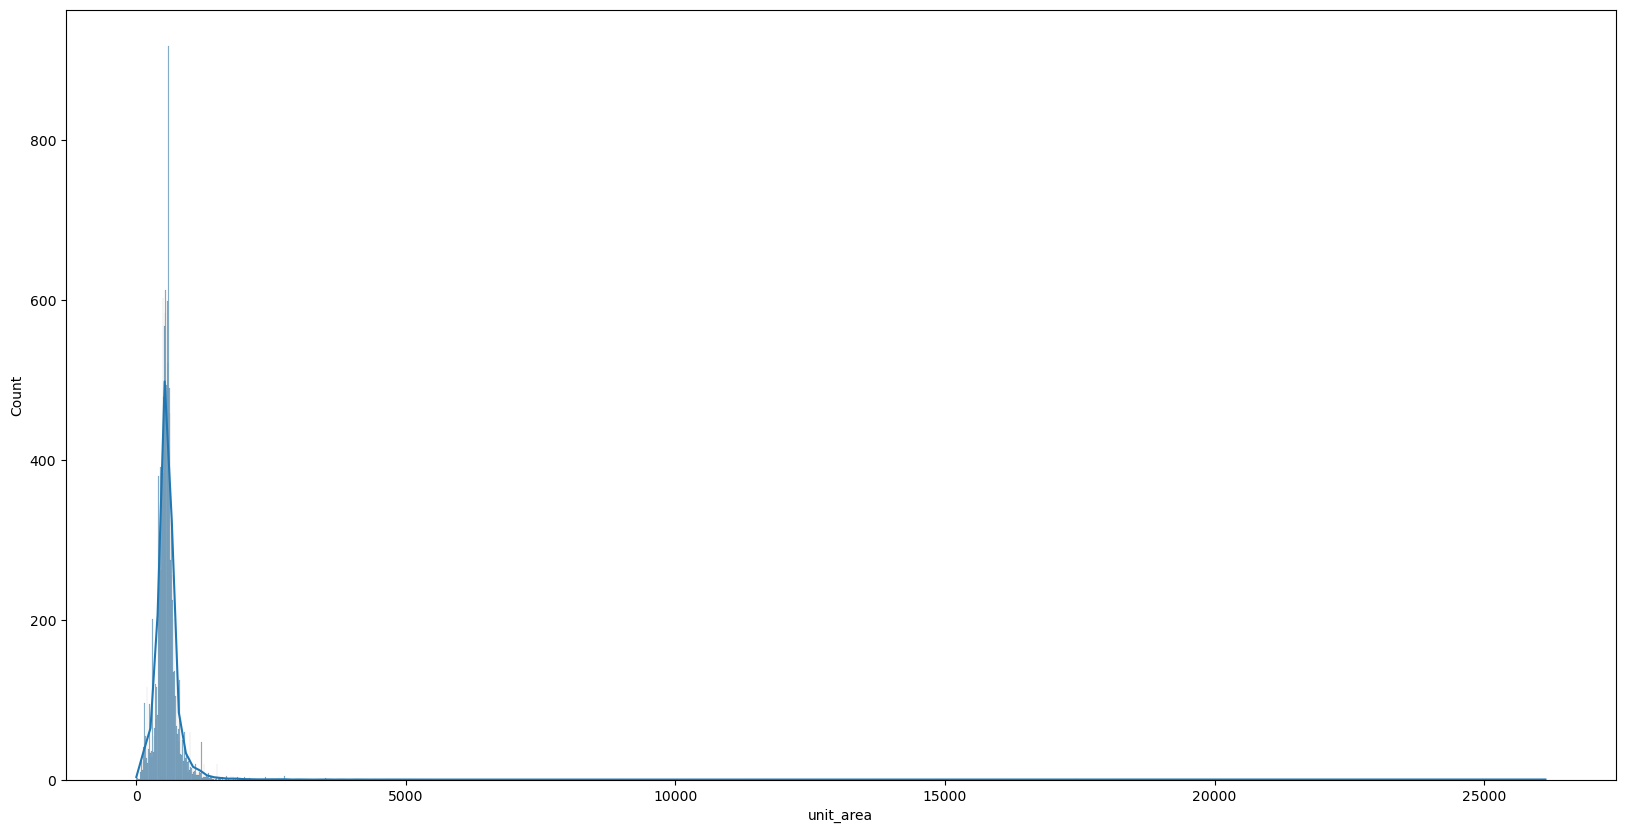

In [262]:
sns.histplot(df5.unit_area,kde=True)

In [263]:
mean=df5.unit_area.mean()
mean

573.8472616105636

In [264]:
std=df5.unit_area.std()
std

388.07998002743966

In [265]:
threshold=2

In [266]:
lower=300
upper=mean+(threshold*std)

In [267]:
df5.shape

(13200, 7)

In [268]:
df6=df5[(df5.unit_area>=lower) & (df5.unit_area<=upper)]

In [269]:
df6.head()

,location,total_sqft,bath,balcony,bhk,price,unit_area
0,Electronic City Phase II,1056.0,2.0,1.0,2,39.07,528.0
1,Chikka Tirupathi,2600.0,5.0,3.0,4,120.00,650.0
2,Uttarahalli,1440.0,2.0,3.0,3,62.00,480.0
3,Lingadheeranahalli,1521.0,3.0,1.0,3,95.00,507.0
4,Kothanur,1200.0,2.0,1.0,2,51.00,600.0


C:\Users\subas\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='unit_area', ylabel='Count'>

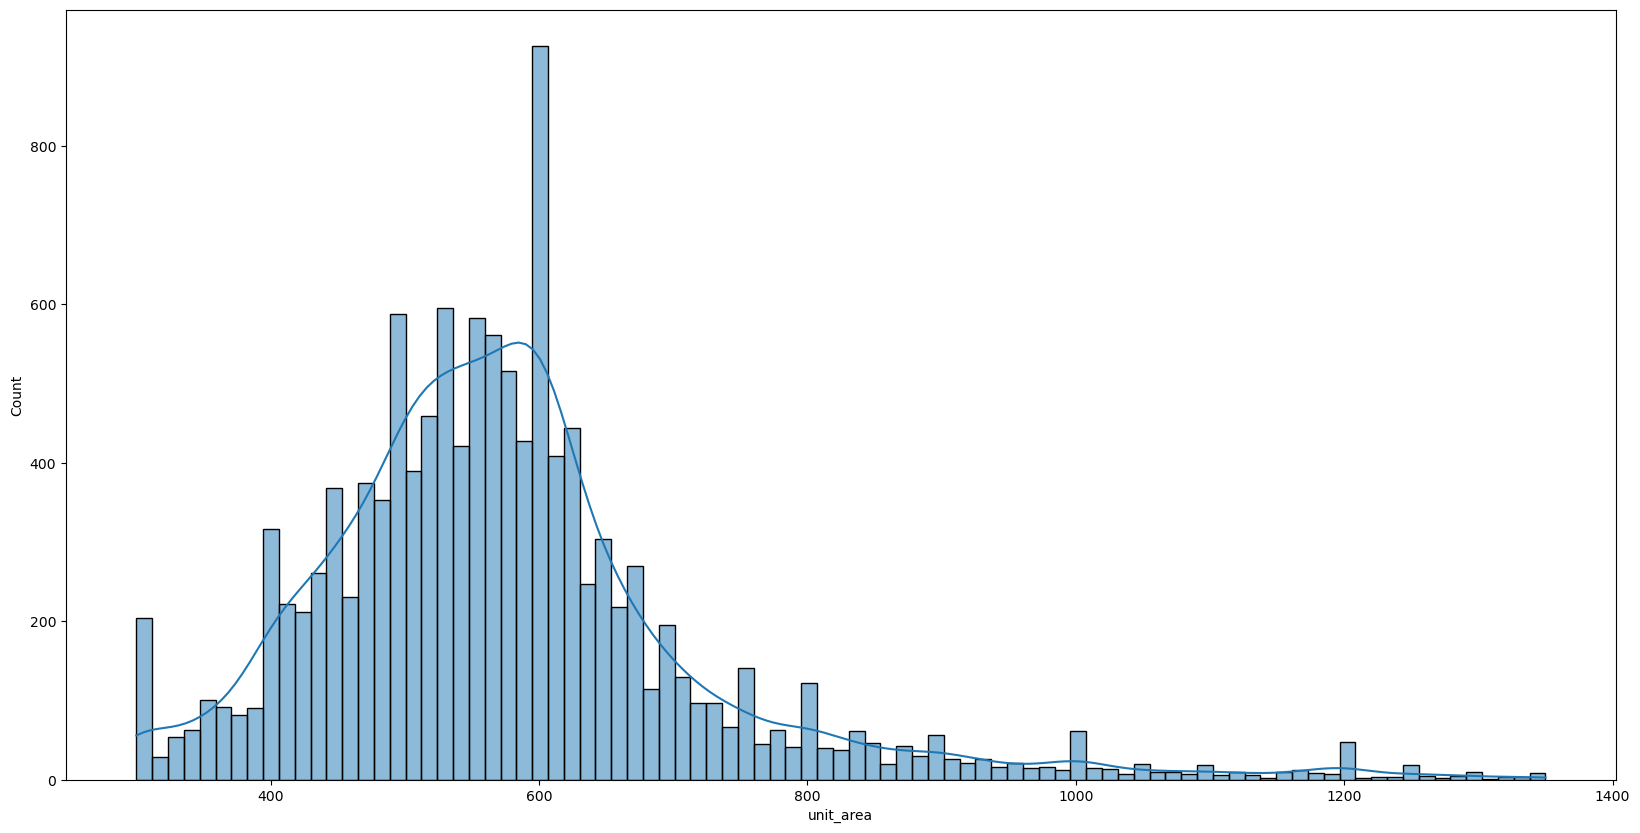

In [270]:
sns.histplot(df6.unit_area,kde=True)

In [271]:
df6.shape

(12335, 7)

In [272]:
df6['unit_price']=(df6.price/df6.total_sqft)*100000

C:\Users\subas\AppData\Local\Temp\ipykernel_20228\217168379.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df6['unit_price']=(df6.price/df6.total_sqft)*100000


In [273]:
df6.head()

,location,total_sqft,bath,balcony,bhk,price,unit_area,unit_price
0,Electronic City Phase II,1056.0,2.0,1.0,2,39.07,528.0,3699.810606
1,Chikka Tirupathi,2600.0,5.0,3.0,4,120.00,650.0,4615.384615
2,Uttarahalli,1440.0,2.0,3.0,3,62.00,480.0,4305.555556
3,Lingadheeranahalli,1521.0,3.0,1.0,3,95.00,507.0,6245.890861
4,Kothanur,1200.0,2.0,1.0,2,51.00,600.0,4250.000000


C:\Users\subas\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='unit_price', ylabel='Count'>

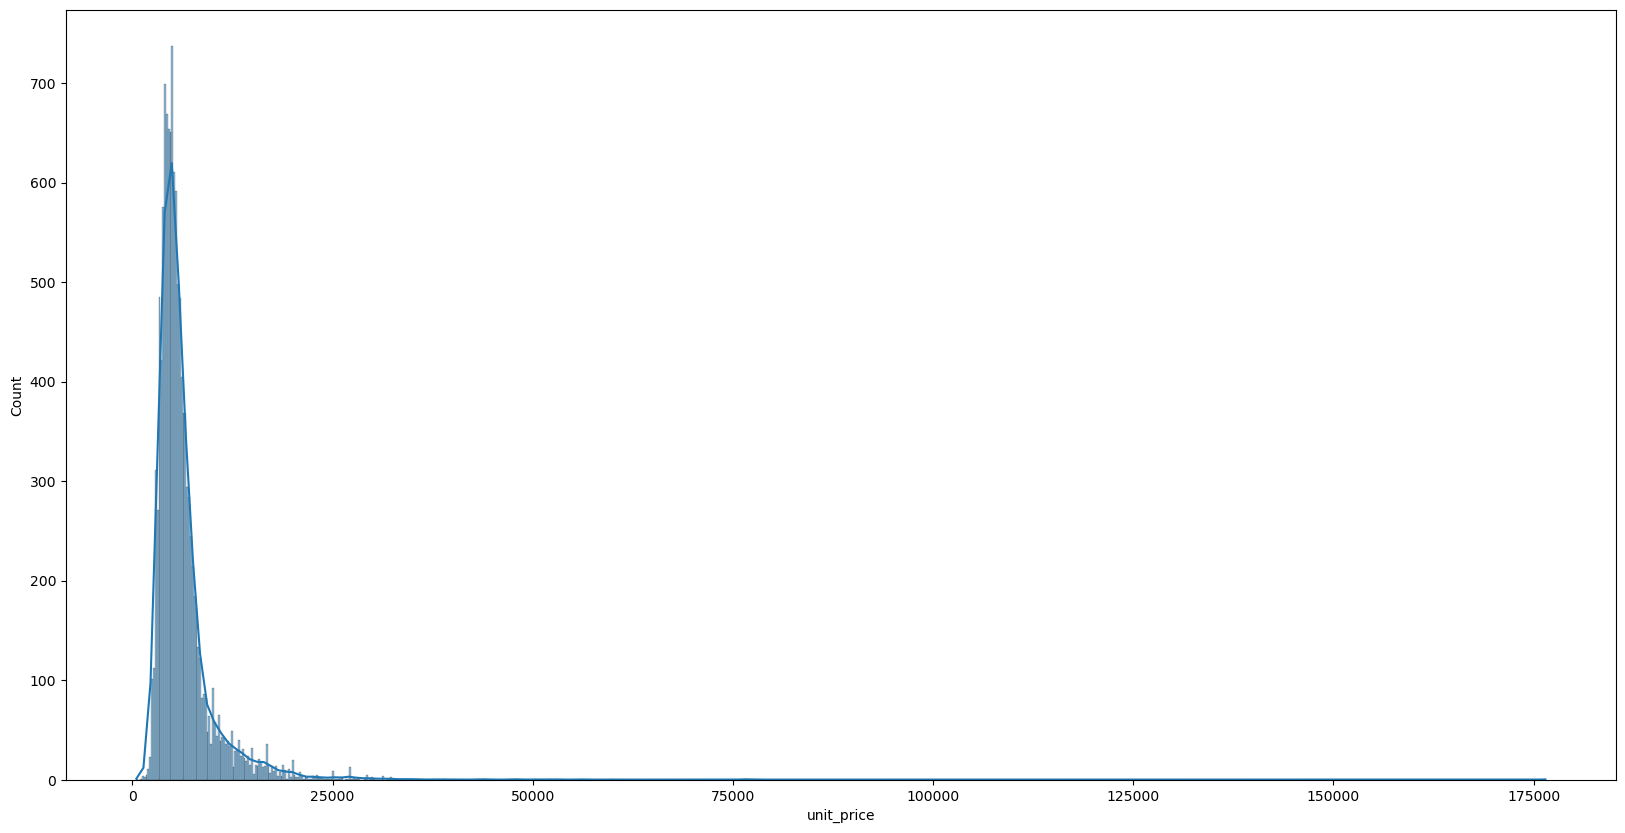

In [274]:
sns.histplot(df6.unit_price,kde=True)

In [275]:
def filter_out(df):
    mean =df.unit_price.mean()
    std =df.unit_price.std()
    threshold= 2
    lower = mean- threshold*std
    upper = mean+ threshold*std
    filtered_df = df[(df.unit_price>=lower)&(df.unit_price<=upper)]
    return filtered_df

In [276]:
df7=filter_out(df6)

In [277]:
df7.shape

(11861, 8)

C:\Users\subas\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='unit_price', ylabel='Count'>

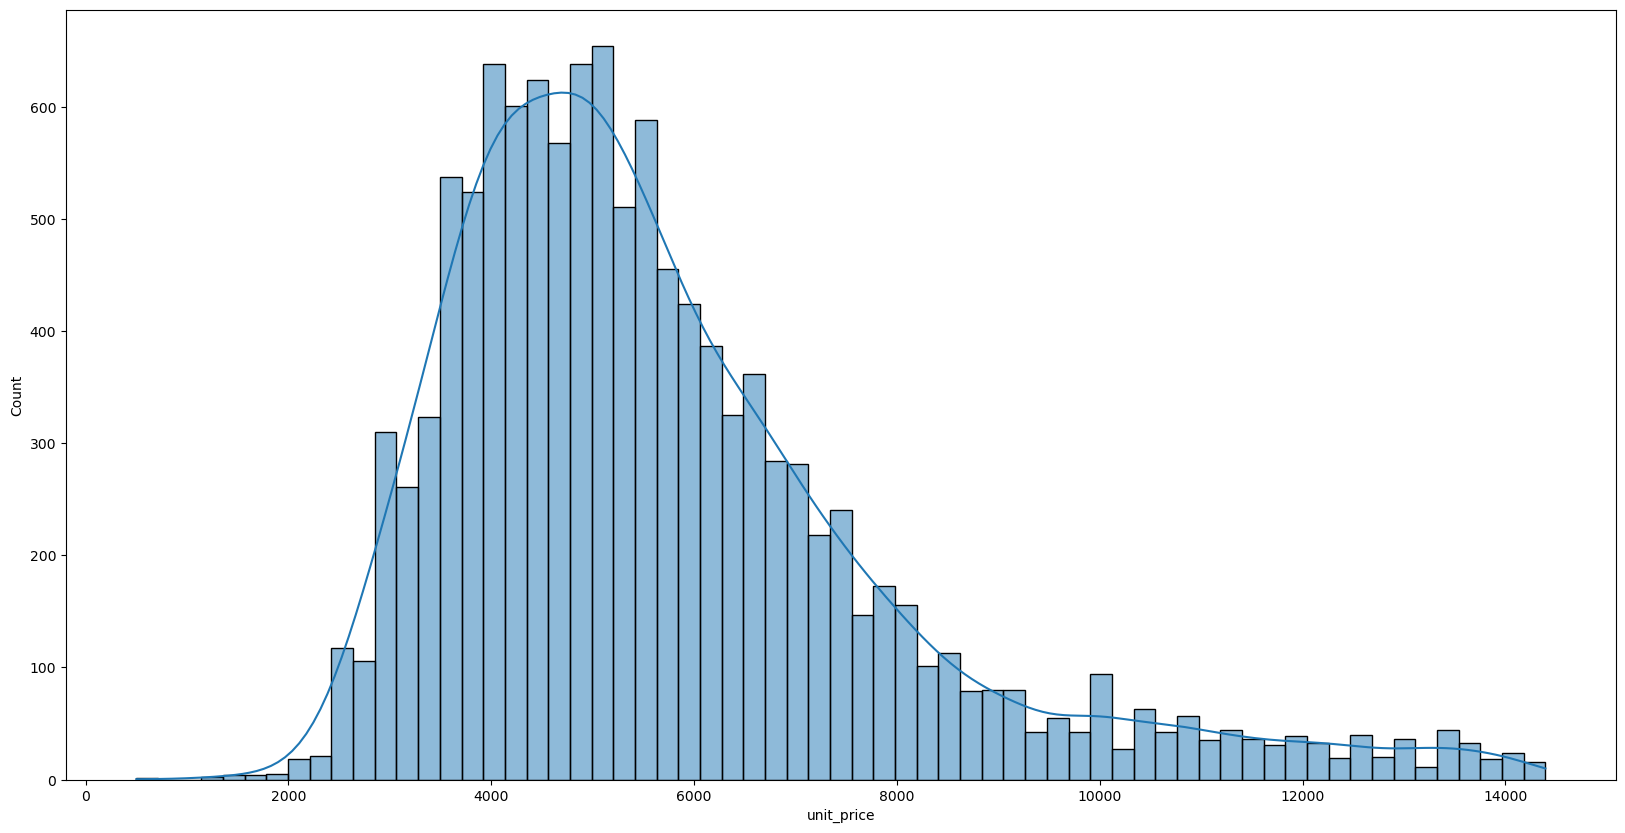

In [278]:
sns.histplot(df7.unit_price,kde=True)

In [279]:
df7.head()

,location,total_sqft,bath,balcony,bhk,price,unit_area,unit_price
0,Electronic City Phase II,1056.0,2.0,1.0,2,39.07,528.0,3699.810606
1,Chikka Tirupathi,2600.0,5.0,3.0,4,120.00,650.0,4615.384615
2,Uttarahalli,1440.0,2.0,3.0,3,62.00,480.0,4305.555556
3,Lingadheeranahalli,1521.0,3.0,1.0,3,95.00,507.0,6245.890861
4,Kothanur,1200.0,2.0,1.0,2,51.00,600.0,4250.000000


In [280]:
 df7.bath.unique()

array([ 2.,  5.,  3.,  4.,  1.,  8.,  6.,  7.,  9., 12., 16., 10., 13.])

In [281]:
df7[~(df7.bath<=df7.bhk+2)]

,location,total_sqft,bath,balcony,bhk,price,unit_area,unit_price
7709,Chikkabanavar,2460.0,7.0,2.0,4,80.0,615.0,3252.03252
12103,Thanisandra,1806.0,6.0,2.0,3,116.0,602.0,6423.03433


In [282]:
df8=df7[df7.bath<=df7.bhk+2]

In [283]:
df8.shape

(11859, 8)

In [284]:
df9=df8.drop(['unit_area','unit_price','balcony'],axis='columns')

###### with or without balcony, the score is same and prediction is also same

In [285]:
df9.head()

,location,total_sqft,bath,bhk,price
0,Electronic City Phase II,1056.0,2.0,2,39.07
1,Chikka Tirupathi,2600.0,5.0,4,120.00
2,Uttarahalli,1440.0,2.0,3,62.00
3,Lingadheeranahalli,1521.0,3.0,3,95.00
4,Kothanur,1200.0,2.0,2,51.00


In [286]:
 df9.sort_values('location',inplace=True)


In [287]:
df9.head(3)

,location,total_sqft,bath,bhk,price
848,1st Block Jayanagar,1630.0,3.0,3,194.0
2152,1st Block Jayanagar,1875.0,2.0,3,235.0
8507,1st Block Jayanagar,1760.0,3.0,3,115.0


In [288]:
df9.reset_index(drop=True,inplace=True)

In [289]:
df9.head(3)

,location,total_sqft,bath,bhk,price
0,1st Block Jayanagar,1630.0,3.0,3,194.0
1,1st Block Jayanagar,1875.0,2.0,3,235.0
2,1st Block Jayanagar,1760.0,3.0,3,115.0


In [290]:
len(df9.location.unique())

241

In [291]:
column_transform= ColumnTransformer([('transform_location',OneHotEncoder(sparse_output=False,drop='first'),['location'])],remainder='passthrough')

In [292]:
df10=column_transform.fit_transform(df9)

In [348]:
ohe_columns = column_transform.named_transformers_['transform_location'].get_feature_names_out(['location'])
ohe_columns= [col.replace('location_','') for col in ohe_columns]
new_columns = list(ohe_columns) + list(df9.columns.drop('location'))

In [349]:
df10.shape

(11859, 244)

In [350]:
df10

array([[  0.  ,   0.  ,   0.  , ...,   3.  ,   3.  , 194.  ],
       [  0.  ,   0.  ,   0.  , ...,   2.  ,   3.  , 235.  ],
       [  0.  ,   0.  ,   0.  , ...,   3.  ,   3.  , 115.  ],
       ...,
       [  0.  ,   0.  ,   0.  , ...,   2.  ,   3.  ,  75.  ],
       [  0.  ,   0.  ,   0.  , ...,   3.  ,   3.  ,  84.83],
       [  0.  ,   0.  ,   0.  , ...,   2.  ,   2.  ,  51.  ]])

In [351]:
len(new_columns)


244

In [352]:
df11 = pd.DataFrame(df10,columns=new_columns)

In [353]:
df11.shape

(11859, 244)

In [354]:
df10.shape

(11859, 244)

In [355]:
df11.head()

,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,9th Phase JP Nagar,AECS Layout,...,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,other,total_sqft,bath,bhk,price
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1630.0,3.0,3.0,194.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1875.0,2.0,3.0,235.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1760.0,3.0,3.0,115.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1000.0,3.0,2.0,60.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1235.0,2.0,2.0,148.0


In [356]:
df11.shape

(11859, 244)

### MODEL TRAINING

In [357]:
X=df11.drop(['price'],axis='columns')
y=df11.price

In [358]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [359]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [360]:
lr.score(X_test,y_test)

0.7516012382612091

In [361]:
y_pred=lr.predict(X_test)

In [362]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
MAE= mean_absolute_error(y_test,y_pred)
MSE= mean_squared_error(y_test,y_pred)
R2_score= r2_score(y_test,y_pred)

In [363]:
R2_score

0.7516012382612091

#### cross validation

In [364]:
from sklearn.model_selection import cross_val_score, ShuffleSplit
cv=ShuffleSplit(n_splits=5,test_size=0.2,random_state=42)
score = cross_val_score(LinearRegression(),X,y,cv=cv,scoring='r2')

In [365]:
score

array([0.75160124, 0.7262435 , 0.7378729 , 0.73698246, 0.74458963])

In [366]:
score.mean()

0.7394579462281666

##### gridsearchCV

In [367]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor


In [368]:
params={
    'linear regression':{
        'model':LinearRegression(),
        'param':{
        }
    },
    
    'lasso':{
        'model': Lasso(),
        'param':{
            'alpha':[0.1,1,10]
        }
    },
    
    'ridge':{
        'model': Ridge(),
        'param':{
            'alpha': [0.1,1,10]
        }
    },
    
    'Decision_tree':{
        'model': DecisionTreeRegressor(),
        'param':{
            'criterion': ['squared_error','friedman_mse'],
            'splitter': ['best','random']
        }
    }
}

In [369]:
cv=ShuffleSplit(n_splits=5,test_size=0.2, random_state=0)

In [370]:
for key, value in params.items():
    gsCV=GridSearchCV(estimator=value['model'],param_grid=value['param'],cv=cv,n_jobs=-1)
    gsCV.fit(X,y)
    print(f'Best score and params of {key} are respectively:')
    print(gsCV.best_score_)
    print(gsCV.best_params_)
    print('*************************')

Best score and params of linear regression are respectively:
0.7416834665848249
{}
*************************
Best score and params of lasso are respectively:
0.72237978016278
{'alpha': 0.1}
*************************
Best score and params of ridge are respectively:
0.7419256692307556
{'alpha': 1}
*************************
Best score and params of Decision_tree are respectively:
0.6360942046674377
{'criterion': 'squared_error', 'splitter': 'best'}
*************************


##### Based on above GridSearchCV, linear regression and ridge regresion seems good. We will use linear regression for our model now.

In [371]:
X.columns

Index(['1st Phase JP Nagar', '2nd Phase Judicial Layout',
       '2nd Stage Nagarbhavi', '5th Block Hbr Layout', '5th Phase JP Nagar',
       '6th Phase JP Nagar', '7th Phase JP Nagar', '8th Phase JP Nagar',
       '9th Phase JP Nagar', 'AECS Layout',
       ...
       'Whitefield', 'Yelachenahalli', 'Yelahanka', 'Yelahanka New Town',
       'Yelenahalli', 'Yeshwanthpur', 'other', 'total_sqft', 'bath', 'bhk'],
      dtype='object', length=243)

##### prediction funciton

In [372]:
X.columns[240]

'total_sqft'

In [381]:
X['1st Phase JP Nagar']

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
11854    0.0
11855    0.0
11856    0.0
11857    0.0
11858    0.0
Name: 1st Phase JP Nagar, Length: 11859, dtype: float64

In [ ]:
X['total_sqft']

In [ ]:
def predict_price(location, sqft, bath, bhk):
    x=np.zeros(len(X.columns))
    if location in X.columns:
        loc_index=X.columns.get_loc(location)
        x[loc_index]=1
    x[X.columns.get_loc('total_sqft')]=sqft
    x[X.columns.get_loc('bath')]=bath
    x[X.columns.get_loc('bhk')]=bhk
    x_df=pd.DataFrame([x],columns=X.columns)
    # Here we can directly pass [x] matrix to the lr.predict (return lr.predict([x])[0])
    # without converting it to  the pandas dataframe,the result is same, but the predict
    # function expects pandas dataframe and with this , we don't get any warning.
    return lr.predict(x_df)[0]

In [374]:
predict_price('1st Block Jayanagar'	,2000, 1 ,1)

210.2551942796157

In [376]:
X.columns.get_loc('1st Phase JP Nagar')

0

In [377]:
predict_price('1st Block Jayanagar',	1760.0,	3.0	,3)

180.31113913597738

In [378]:
predict_price('1st Block Jayanagar',	1875.0,	2.0,	3)

182.64494699891648

##### Exporting the model and column names

In [379]:
import pickle
with open('banglore_home_price_model.pickle','wb') as f:
    pickle.dump(lr,f)

In [380]:
import json
columns={
    'data_columns':[col.lower() for col in X.columns]
}
with open('columns.json','w') as f:
    f.write(json.dumps(columns))